# Prequential Evaluation capyMOA

In [ ]:
from capymoa.anomaly import OnlineIsolationForest
from capymoa.anomaly import HalfSpaceTrees
from capymoa.evaluation.visualization import plot_windowed_results
from capymoa.evaluation import prequential_evaluation_anomaly
from src.Data.Processor import DataStreamProcessor
import pandas as pd

df = pd.read_csv('data/15k/Consistência/Consistência_2000.csv')

processor = DataStreamProcessor(logging=True)

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=False, 
    normalize_method="MinMaxScaler", 
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

oif = OnlineIsolationForest(schema=stream.get_schema())
hst = HalfSpaceTrees(schema=stream.get_schema())

results_hst = prequential_evaluation_anomaly(
    stream=stream, learner=hst, window_size=200
)

results_oif = prequential_evaluation_anomaly(
    stream=stream, learner=oif, window_size=200
)

In [ ]:
# print("Half-Space Trees Results:")
# print(f"AUC: {results_hst.auc()}")
# print(f"Accuracy: {results_hst.accuracy()}")
# print(f"Recall: {results_hst.recall()}")

# print("Online Isolation Forest Results:")
# print(f"AUC: {results_oif.auc()}")
# print(f"Accuracy: {results_oif.accuracy()}")
# print(f"Recall: {results_oif.recall()}")

display(results_hst.windowed.metrics_per_window())
plot_windowed_results(results_hst, results_oif, metric="Accuracy", save_only=False)
plot_windowed_results(results_hst, results_oif, metric="Recall", save_only=False)
plot_windowed_results(results_hst, results_oif, metric="auc", save_only=False)

# Execução Pipelines

## Otimização Optuna

### Melhores Features

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from src.Data.Processor import DataStreamProcessor

# Definição dos datasets
categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '200', '1000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

# Dicionário/Counter para armazenar a contagem global das features
contagem_features = Counter()

for dataset_path in datasets:
    print(f"-> Analisando: {dataset_path}")
    
    try:
        df = pd.read_csv(dataset_path)
    except FileNotFoundError:
        print(f"   [!] Arquivo não encontrado. Pulando...")
        continue
    
    processor = DataStreamProcessor(logging=False)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=0.85,
        top_n_features=25,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    # Adiciona as 25 features deste cenário ao nosso contador global
    contagem_features.update(features)

# Pega as 25 features que mais apareceram somando todos os cenários
top_25_globais = contagem_features.most_common(25)
nomes_features = [f[0] for f in top_25_globais]

print("\nfeatures = [")
for feat in nomes_features:
    print(f"    '{feat}',")
print("]")

### Otimização dos Modelos

In [8]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Optimizer import AnomalyOptunaOptimizer
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Definição dos datasets
categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '200', '1000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

features = [
    'Fwd Packet Length Min',
    'Total Fwd Packets',
    'Fwd Packet Length Max',
    'Packet Length Variance',
    'Init_Win_bytes_forward',
    'Flow IAT Mean',
    'Fwd Packets/s',
    'Fwd Packet Length Std',
    'Flow Duration',
    'Total Backward Packets',
    'URG Flag Count',
    'Init_Win_bytes_backward',
    'Flow IAT Min',
    'Bwd Packets/s',
    'Bwd IAT Mean',
    'Down/Up Ratio',
    'Bwd IAT Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Fwd Header Length',
    'Total Length of Fwd Packets',
    'ACK Flag Count',
    'Active Mean',
    'Fwd Packet Length Mean',
    'Fwd PSH Flags',
]

for dataset_path in datasets:
    print(f"\nIniciando otimização para: {dataset_path}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
        imputation_method='mediana'
    )
    
    optimizer = AnomalyOptunaOptimizer(
        stream=stream,
        n_trials=5,
        discretization_threshold='params',
        target_class=0,
        target_names=targets
    )

    # melhor_hst = optimizer.optimize('HST')
    # melhor_oif = optimizer.optimize('OIF')
    melhor_aif = optimizer.optimize('AIF')
    # melhor_aif = optimizer.optimize('AE', warmup_instances=1000)
    # melhor_rrcf = optimizer.optimize('RRCF')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Iniciando otimização para: data/15k/Consistência/Consistência_25.csv

[AIF] Iniciando otimização focada no F1-Score (Classe 0) com 5 trials...
Trial 1/5 | F1: 99.76 | Prec: 99.52 | Rec: 100.00 | Params: {'dynamic_threshold': 0.8500000000000001, 'window_size': 768, 'height': 10}
Trial 2/5 | F1: 99.76 | Prec: 99.52 | Rec: 100.00 | Params: {'dynamic_threshold': 0.8500000000000001, 'window_size': 896, 'height': 8}
Trial 3/5 | F1: 99.76 | Prec: 99.52 | Rec: 100.00 | Params: {'dynamic_threshold': 0.7000000000000001, 'window_size': 128, 'height': 12}
Trial 4/5 | F1: 81.55 | Prec: 100.00 | Rec: 68.85 | Params: {'dynamic_threshold': 0.35000000000000003, 'window_size': 256, 'height': 14}
Trial 5/5 | F1: 0.00 | Prec: 0.00 | Rec: 0.00 | Params: {'dynamic_threshold': 0.25, 'window_size': 768, 'height': 9}

[AIF] OTIMIZAÇÃO FINALIZADA
Melhor Trial: 1
Melhor Resultado -> F1: 99.76 | Prec: 99.52 | Rec: 100.00
Melh

## Resultados

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Iniciando treinamento para: Consistência_25

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 95.03    | 99.97    | 90.56    | 0.197    | 4.89      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.03%   | Recuperação (1000 amostras): +0.95%
  -> Ataque 2: Passagem: -0.01%   | Recuperação (1000 amostras): +0.15%
  -> Ataque 3: Passagem: -0.00%   | Recuperação (1000 amostras): +0.08%



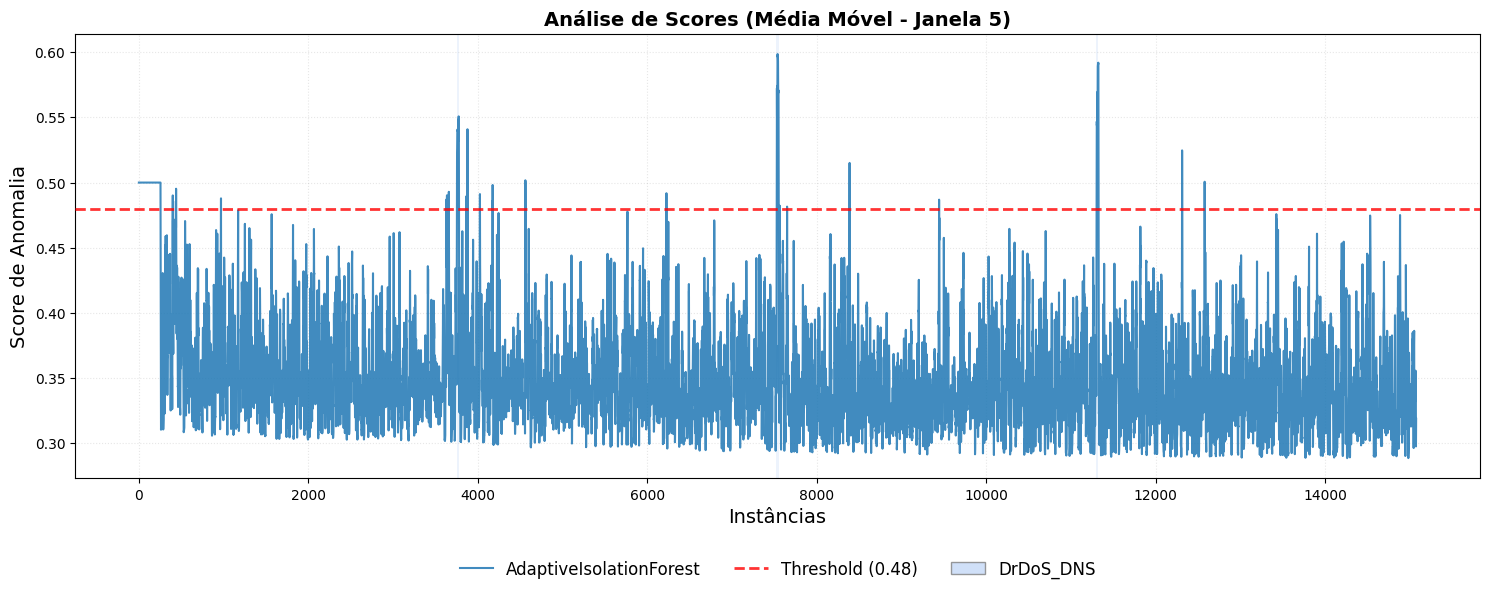

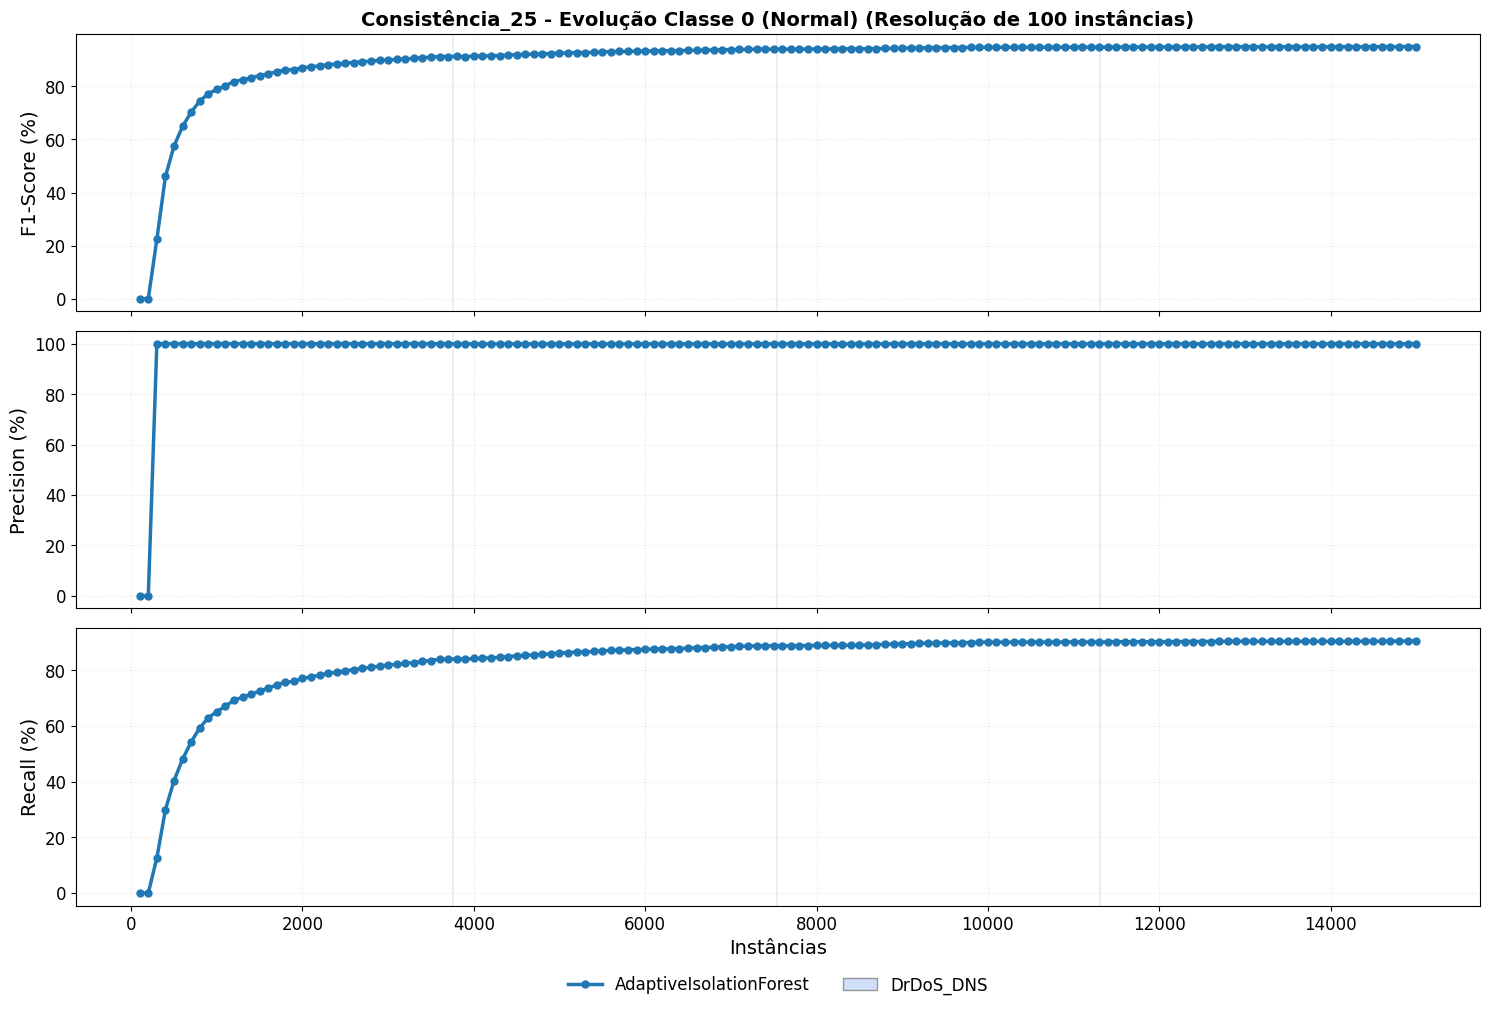


Iniciando treinamento para: Consistência_200

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 94.55    | 99.61    | 89.98    | 0.424    | 4.67      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.18%   | Recuperação (1000 amostras): +0.94%
  -> Ataque 2: Passagem: -0.09%   | Recuperação (1000 amostras): +0.14%
  -> Ataque 3: Passagem: -0.14%   | Recuperação (1000 amostras): +0.07%



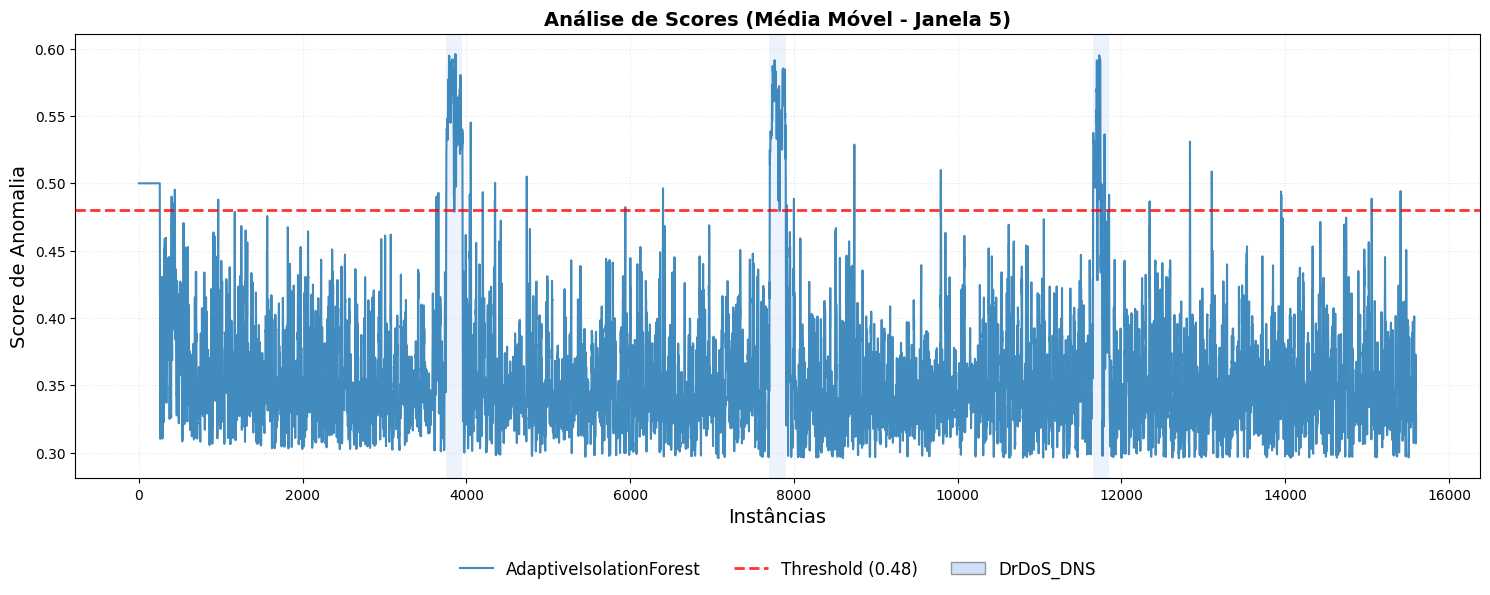

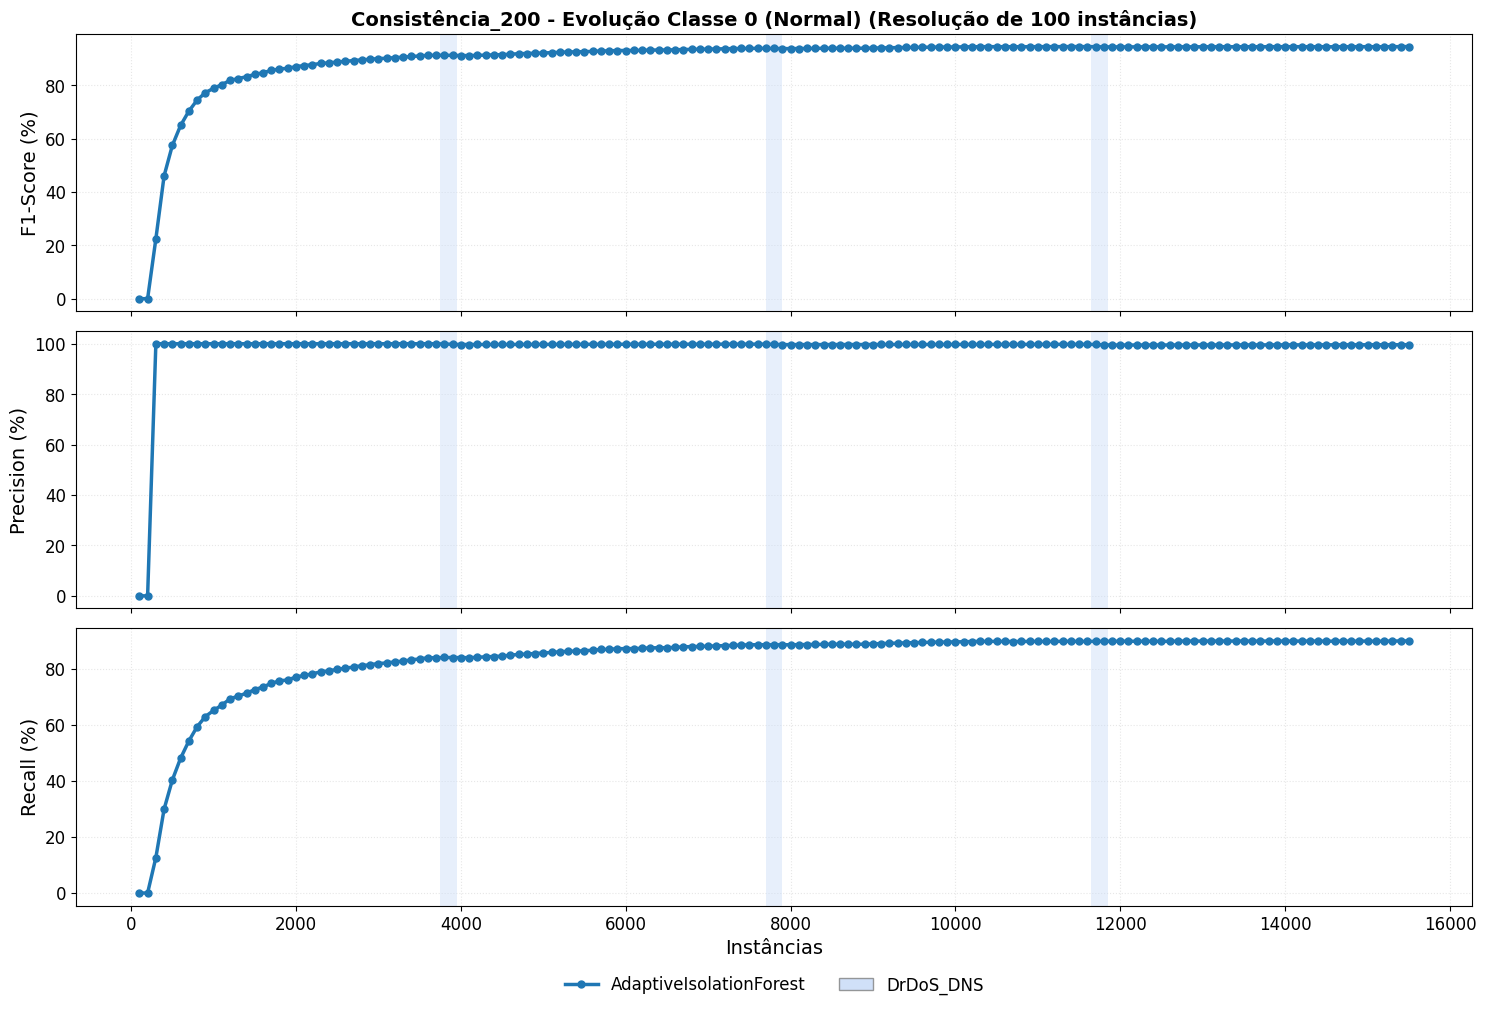


Iniciando treinamento para: Consistência_1000

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 93.31    | 96.82    | 90.04    | 0.620    | 5.74      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.90%   | Recuperação (1000 amostras): +1.02%
  -> Ataque 2: Passagem: -0.99%   | Recuperação (1000 amostras): +0.31%
  -> Ataque 3: Passagem: -0.85%   | Recuperação (1000 amostras): +0.19%



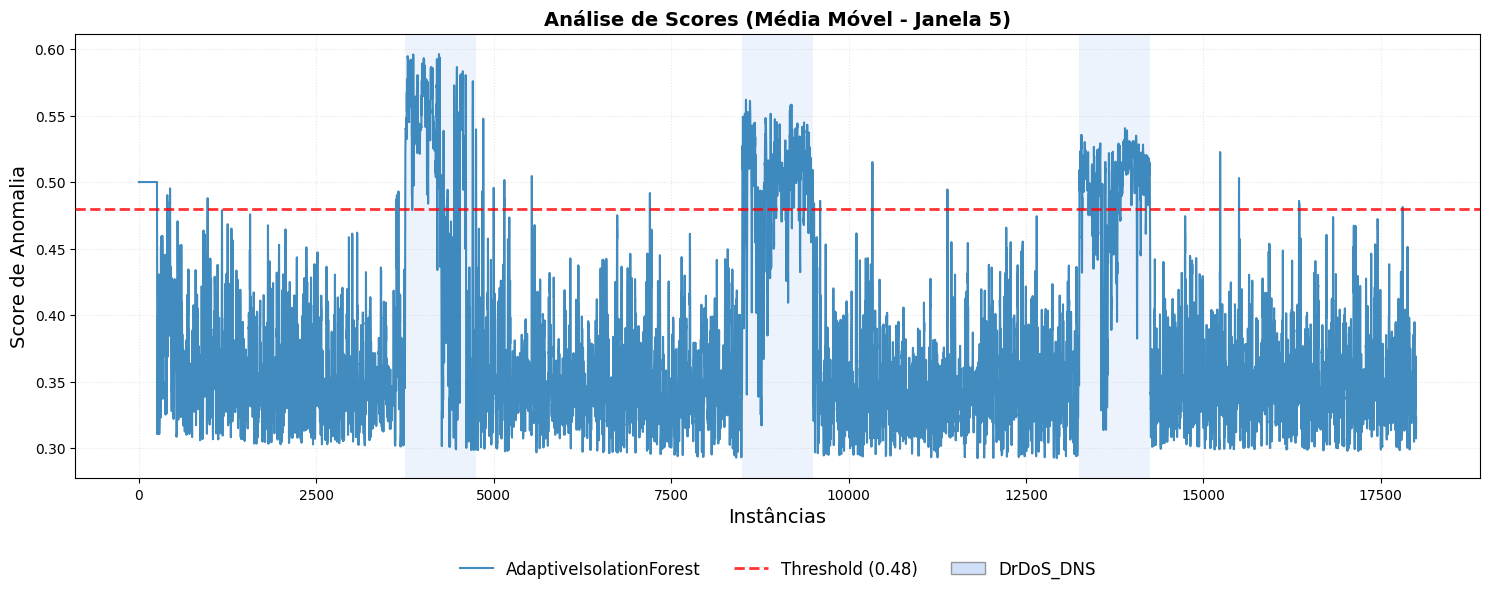

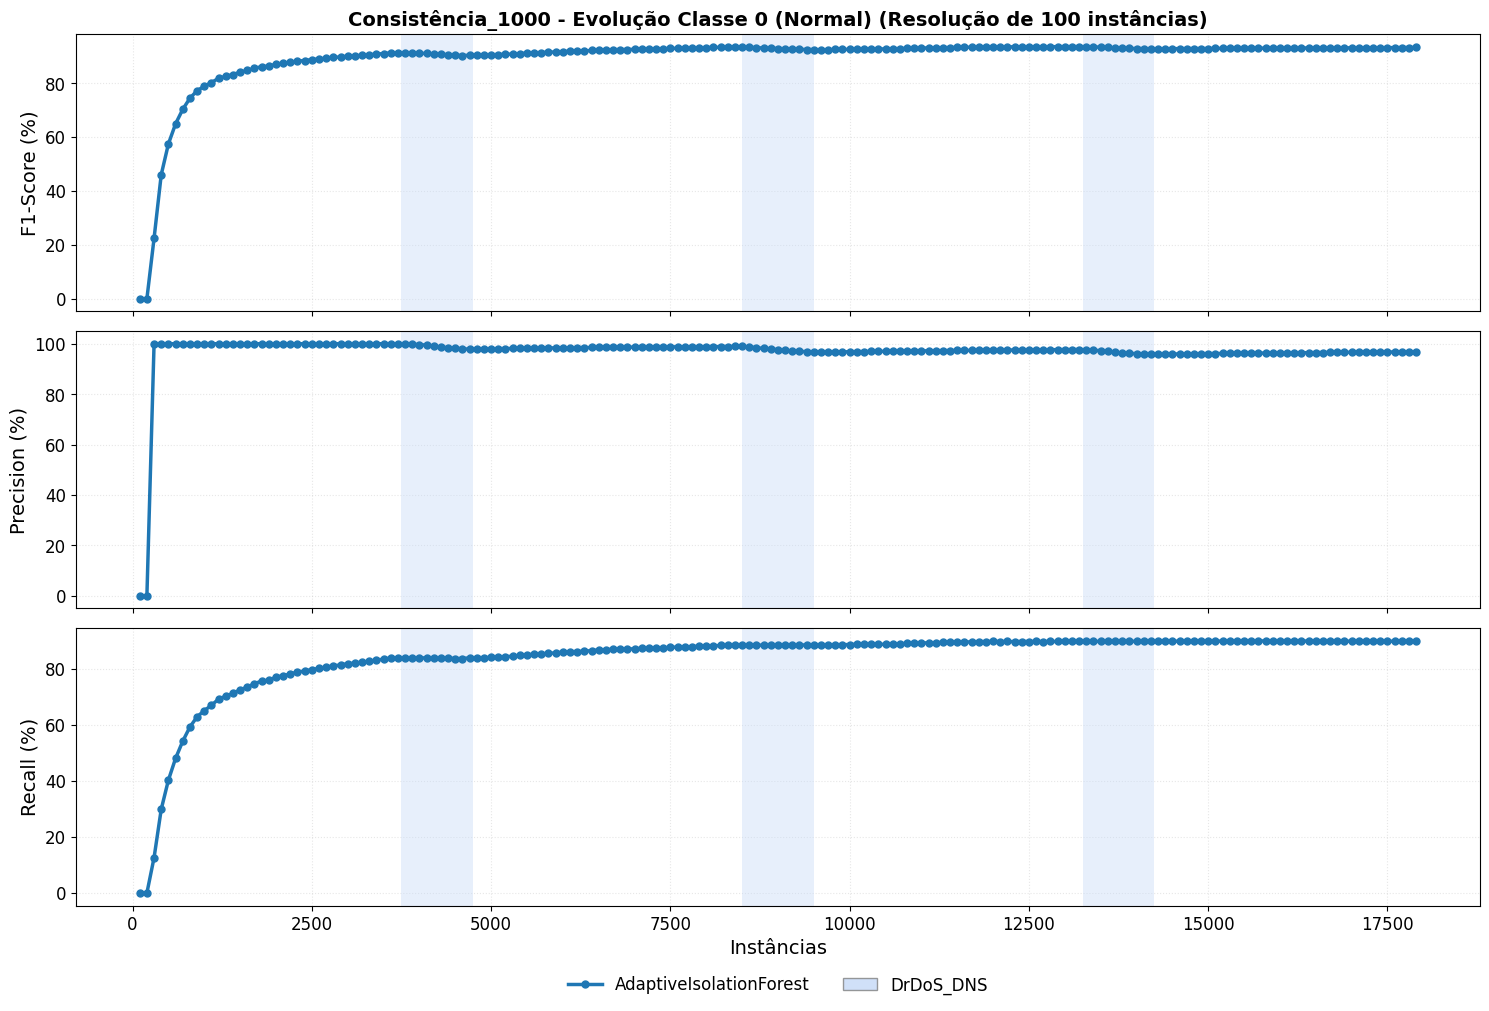


Iniciando treinamento para: Generalização_25

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 95.14    | 99.97    | 90.75    | 0.200    | 4.98      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.03%   | Recuperação (1000 amostras): +0.95%
  -> Ataque 2: Passagem: -0.01%   | Recuperação (1000 amostras): +0.14%
  -> Ataque 3: Passagem: -0.00%   | Recuperação (1000 amostras): +0.11%



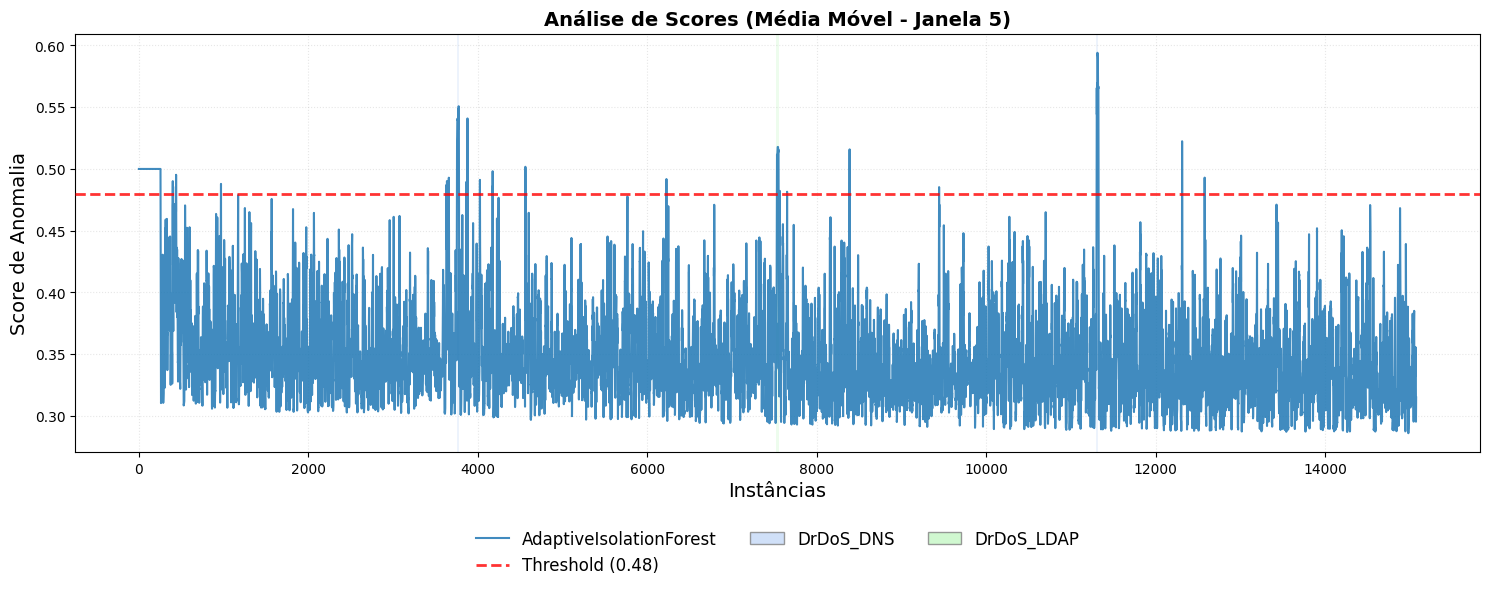

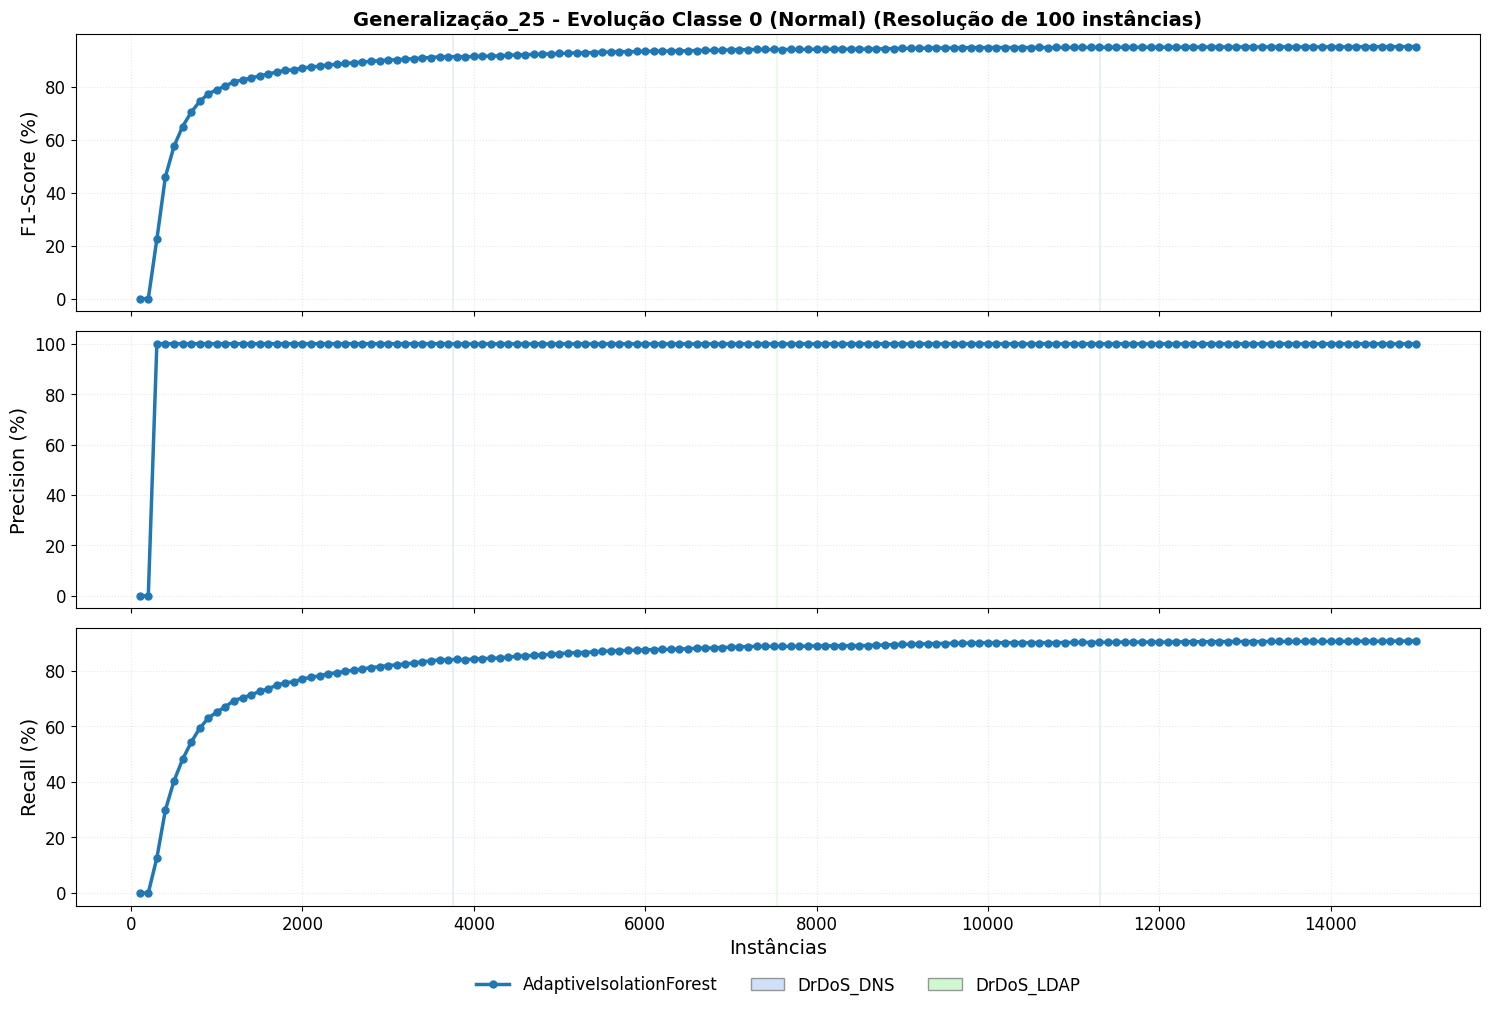


Iniciando treinamento para: Generalização_200

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 94.65    | 99.82    | 89.99    | 0.477    | 4.64      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.18%   | Recuperação (1000 amostras): +0.94%
  -> Ataque 2: Passagem: -0.01%   | Recuperação (1000 amostras): +0.13%
  -> Ataque 3: Passagem: -0.06%   | Recuperação (1000 amostras): +0.06%



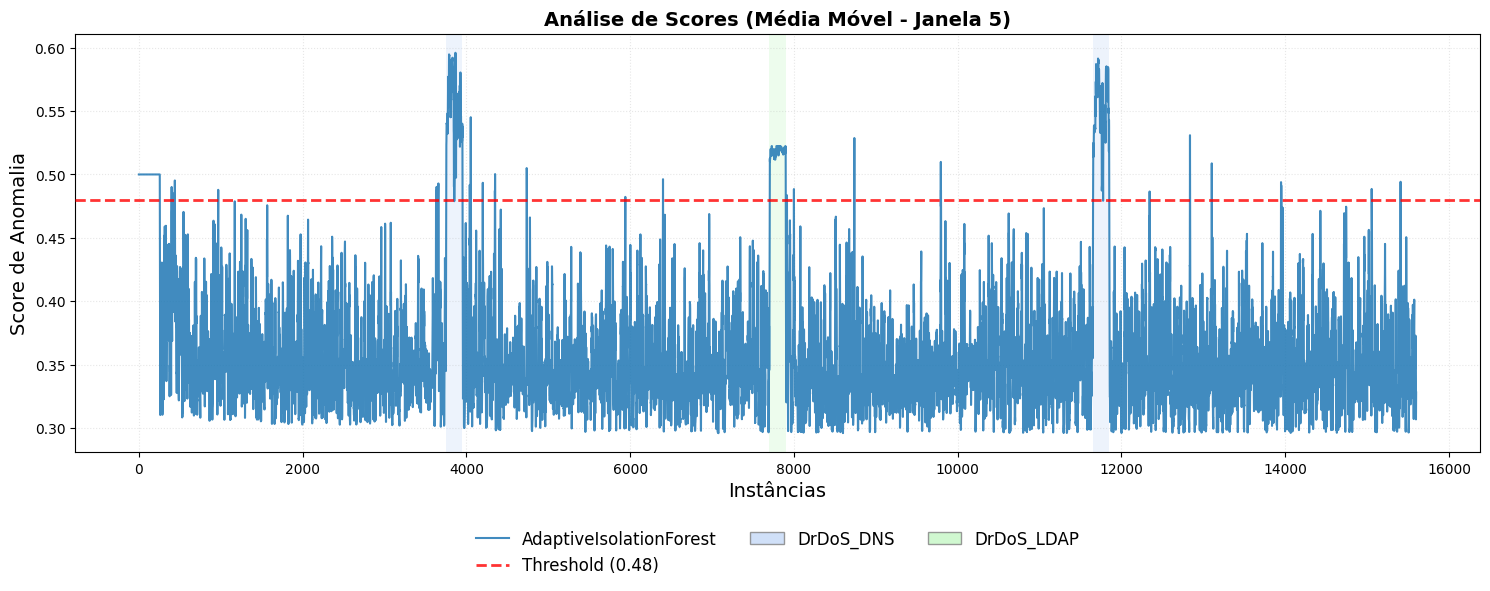

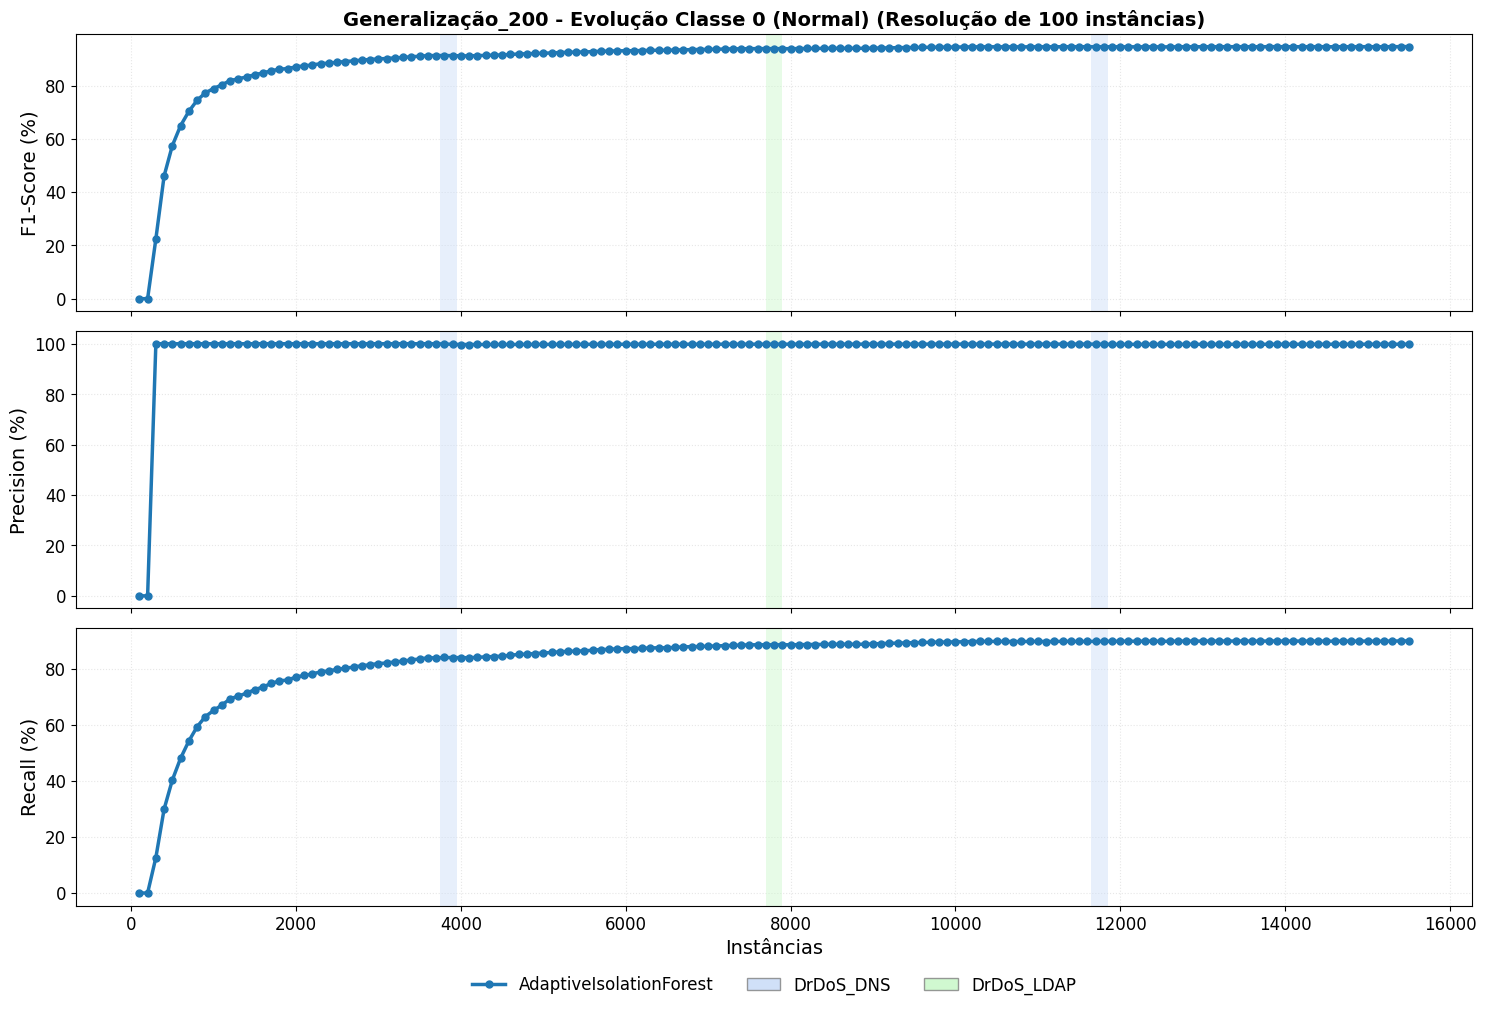


Iniciando treinamento para: Generalização_1000

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 93.89    | 98.26    | 89.89    | 0.683    | 5.93      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.90%   | Recuperação (1000 amostras): +1.02%
  -> Ataque 2: Passagem: -0.01%   | Recuperação (1000 amostras): +0.18%
  -> Ataque 3: Passagem: -0.68%   | Recuperação (1000 amostras): +0.12%



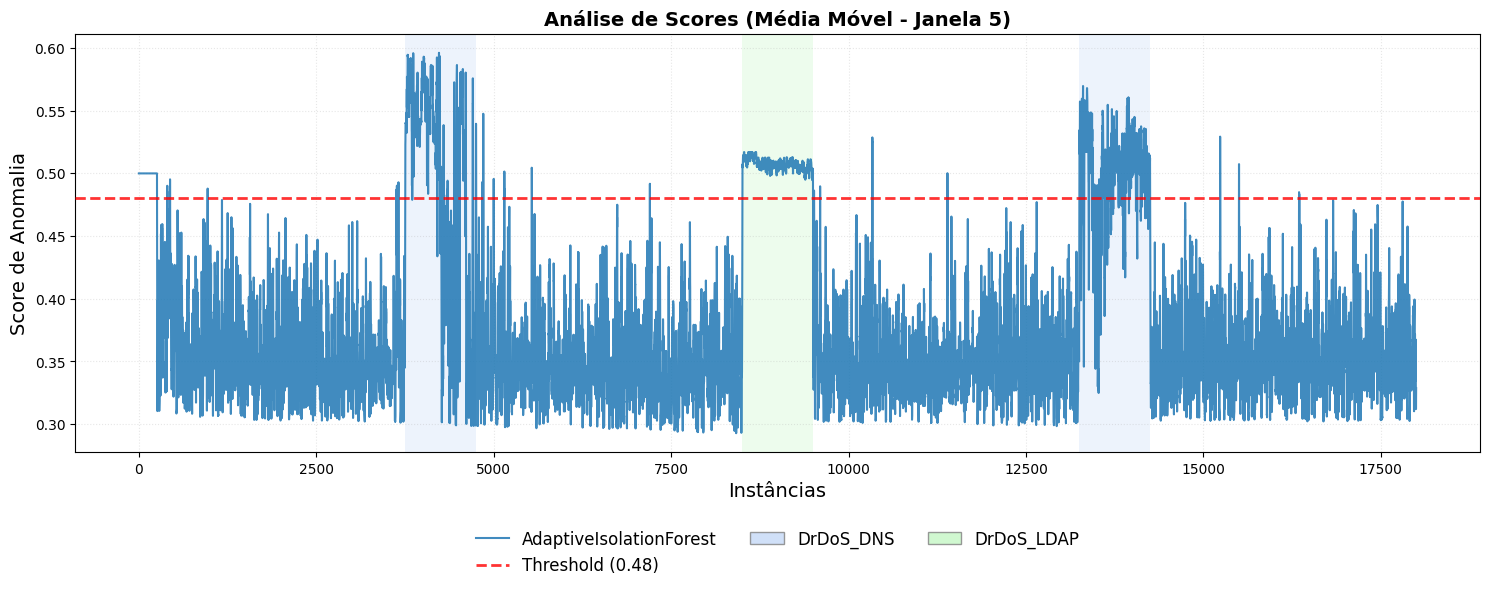

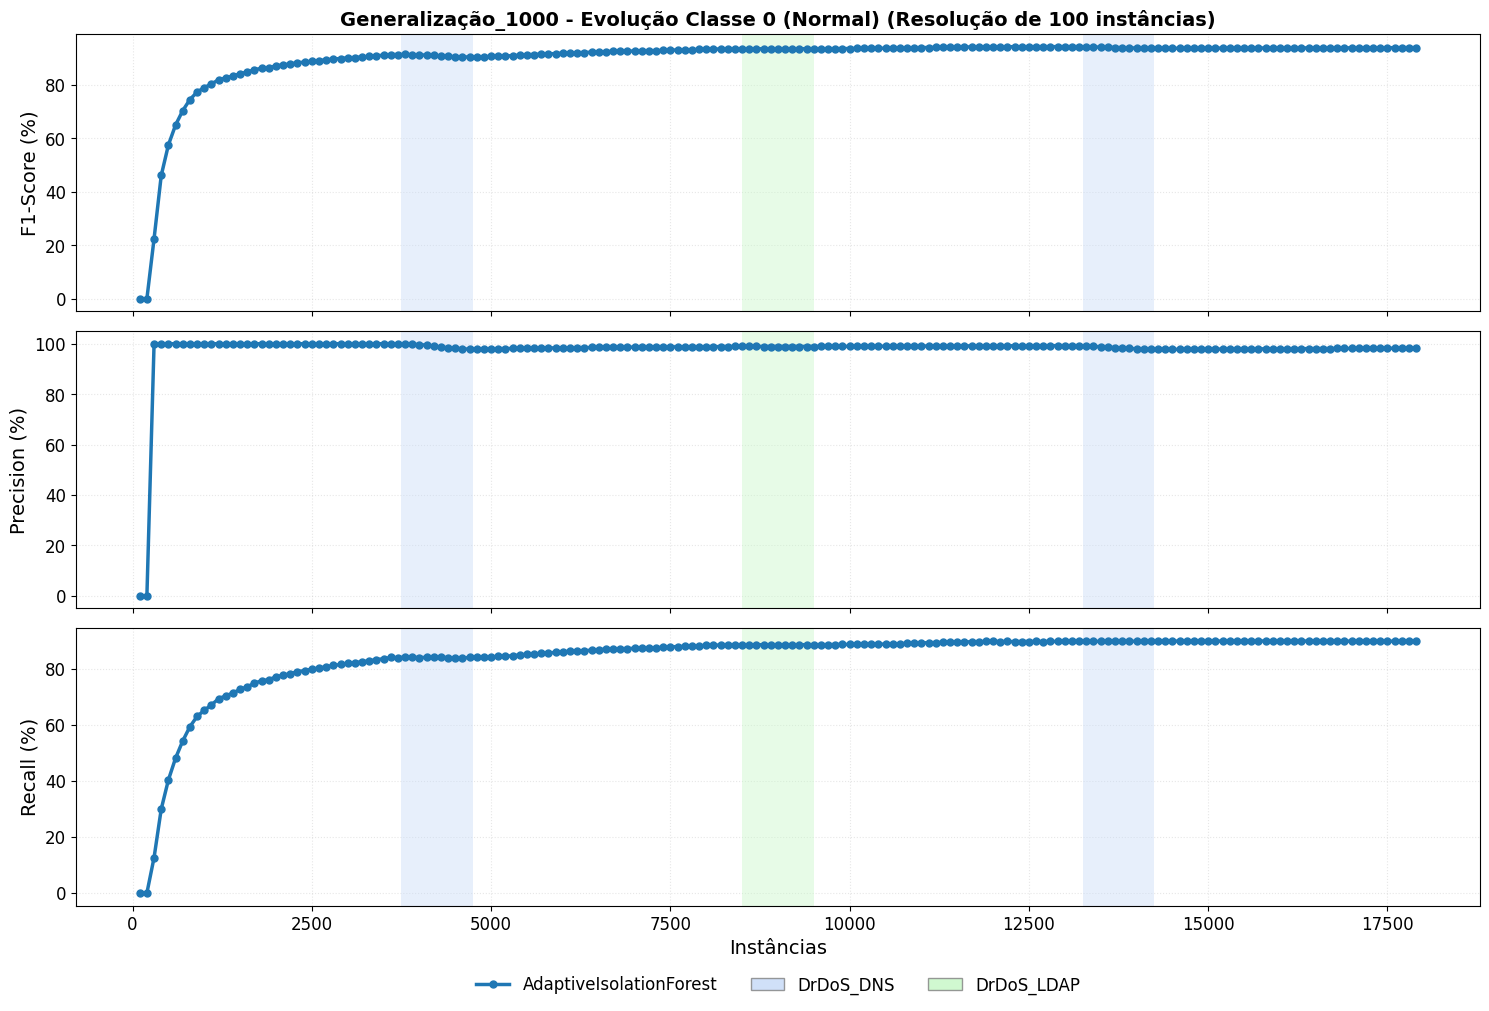


Iniciando treinamento para: Adaptação_25

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 95.04    | 99.82    | 90.70    | 0.129    | 5.06      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.03%   | Recuperação (1000 amostras): +0.95%
  -> Ataque 2: Passagem: -0.14%   | Recuperação (1000 amostras): +0.16%
  -> Ataque 3: Passagem: -0.00%   | Recuperação (1000 amostras): +0.11%



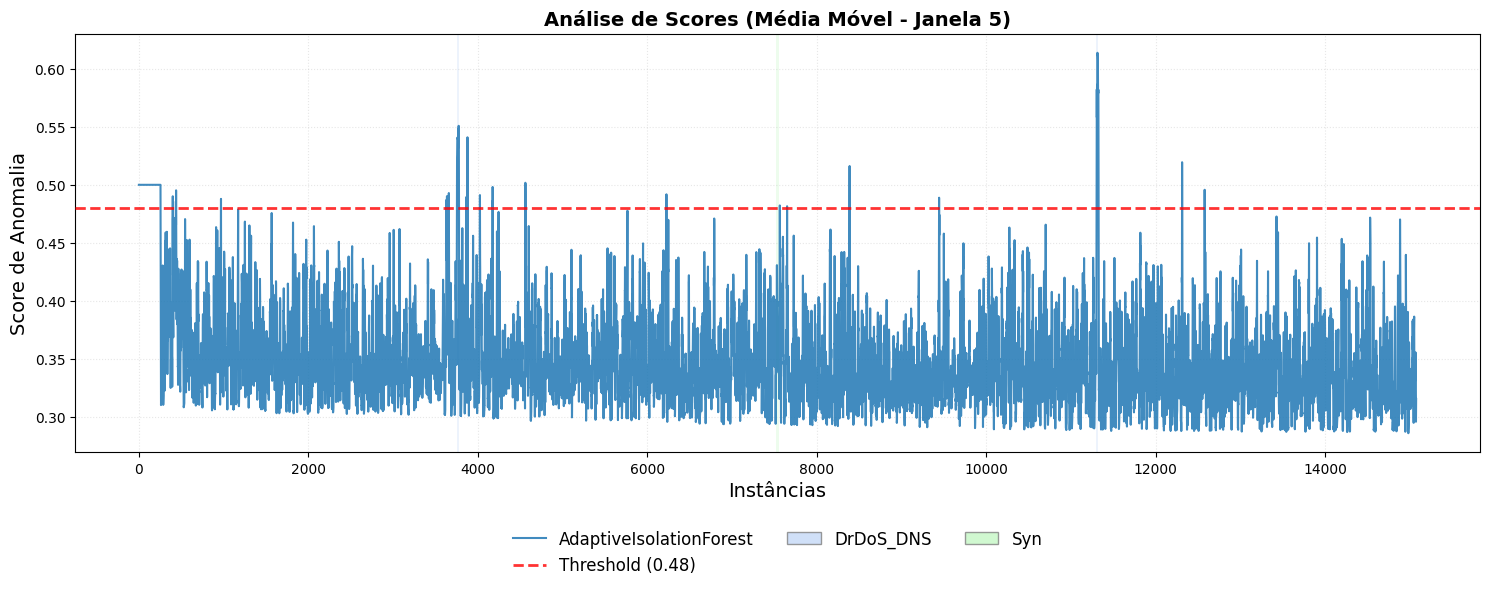

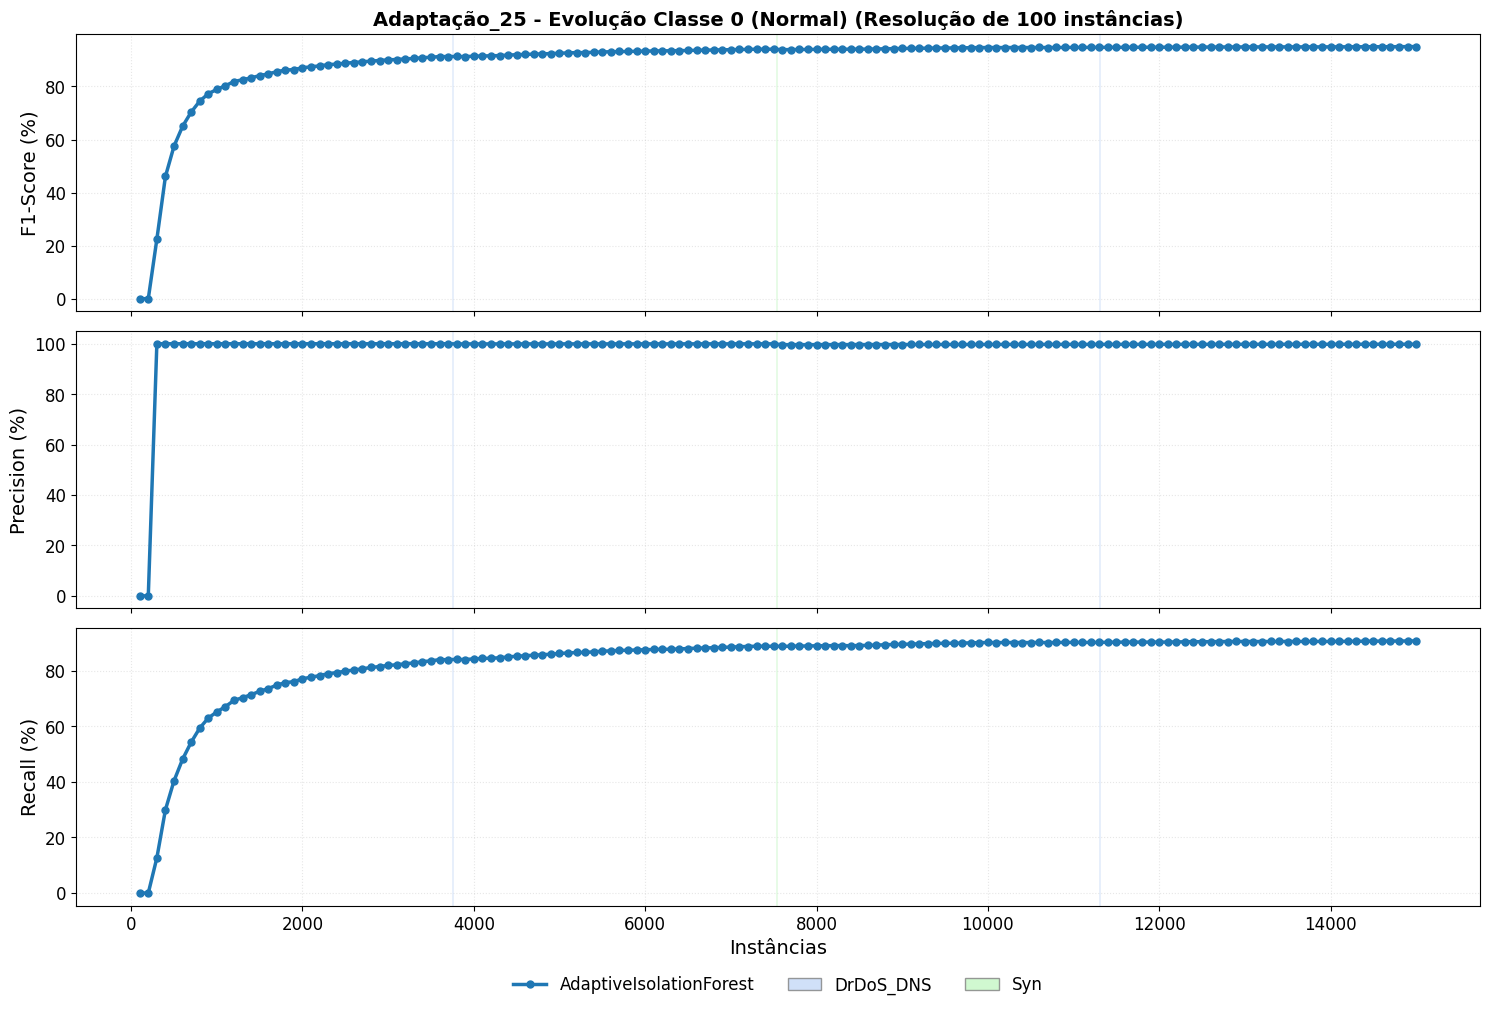


Iniciando treinamento para: Adaptação_200

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 94.03    | 98.45    | 89.99    | 0.305    | 4.78      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.18%   | Recuperação (1000 amostras): +0.94%
  -> Ataque 2: Passagem: -1.24%   | Recuperação (1000 amostras): +0.27%
  -> Ataque 3: Passagem: -0.06%   | Recuperação (1000 amostras): +0.13%



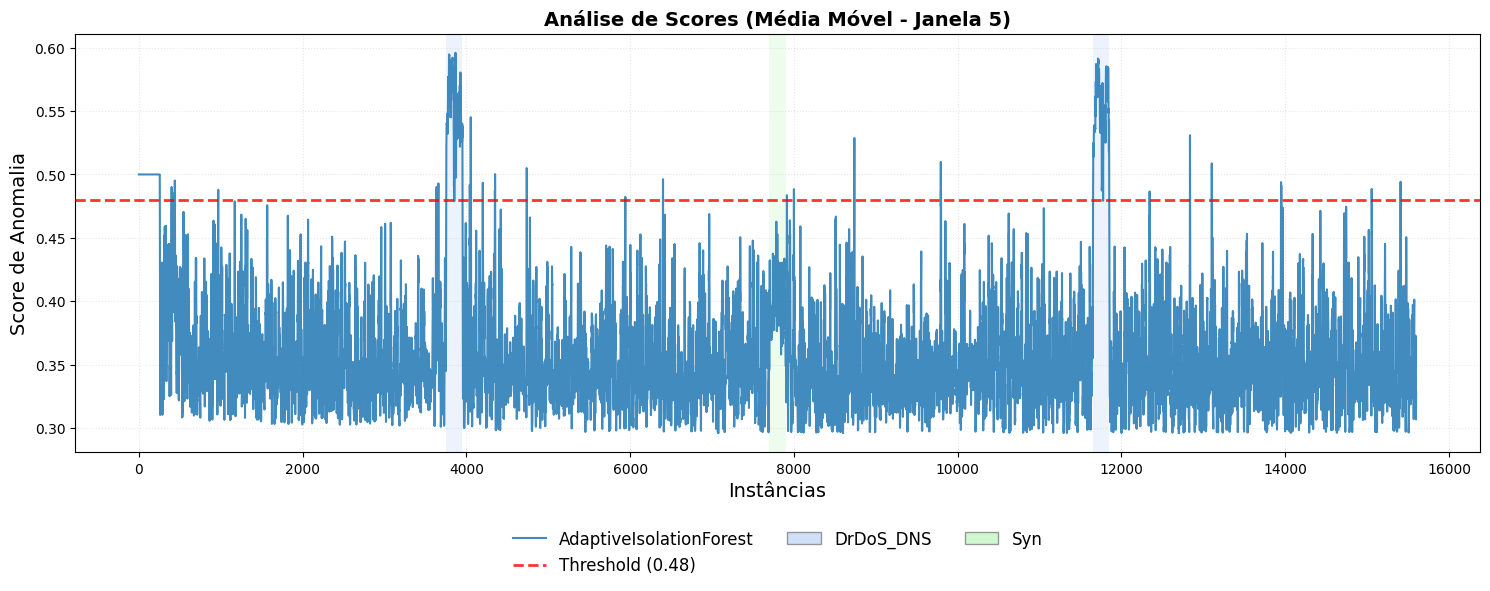

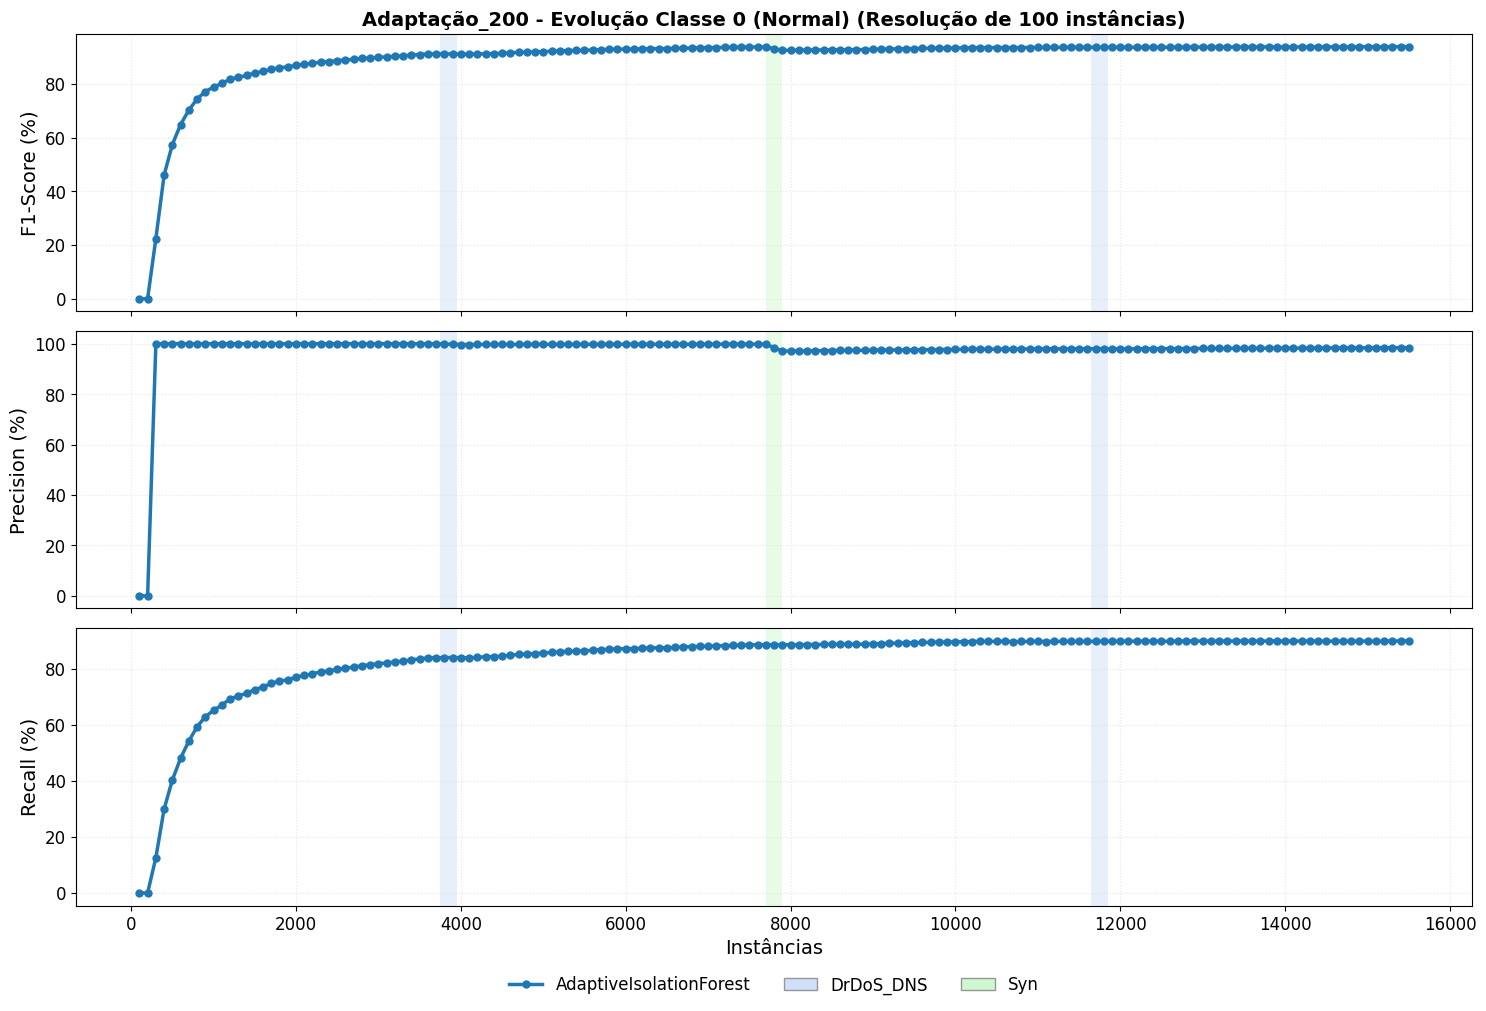


Iniciando treinamento para: Adaptação_1000

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 91.05    | 91.92    | 90.20    | 0.407    | 5.93      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.90%   | Recuperação (1000 amostras): +1.02%
  -> Ataque 2: Passagem: -5.55%   | Recuperação (1000 amostras): +0.80%
  -> Ataque 3: Passagem: -0.75%   | Recuperação (1000 amostras): +0.45%



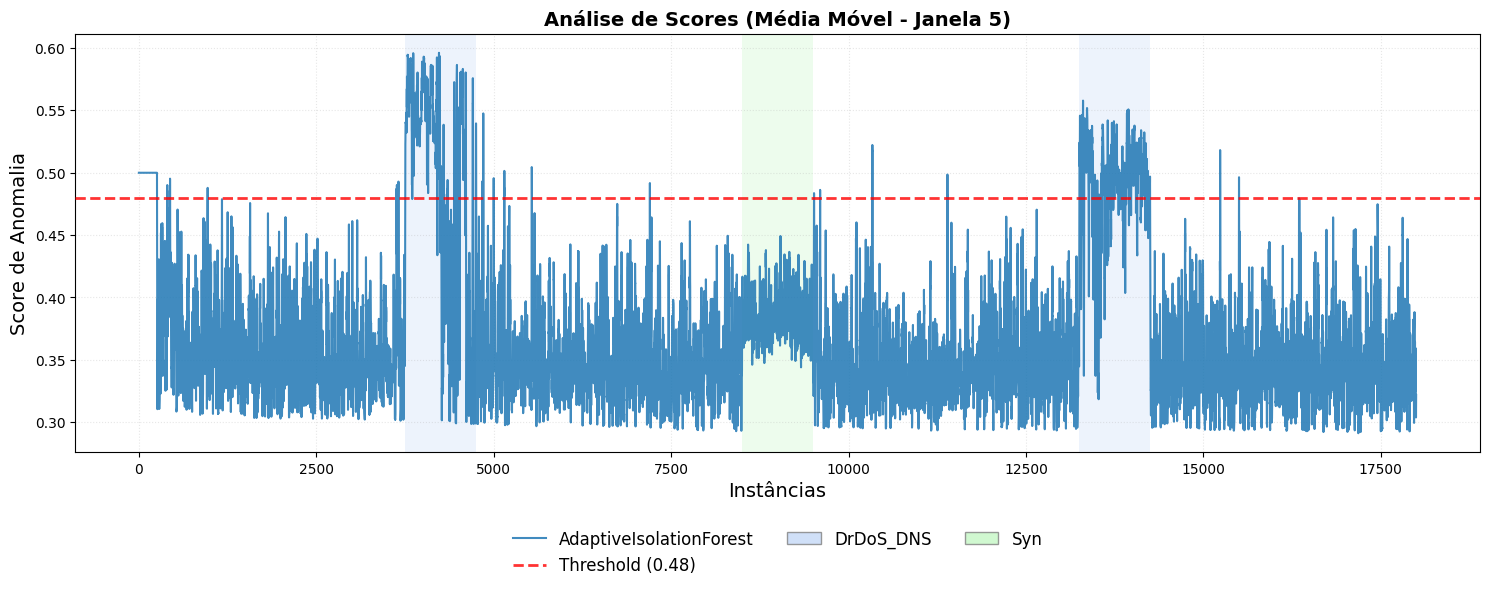

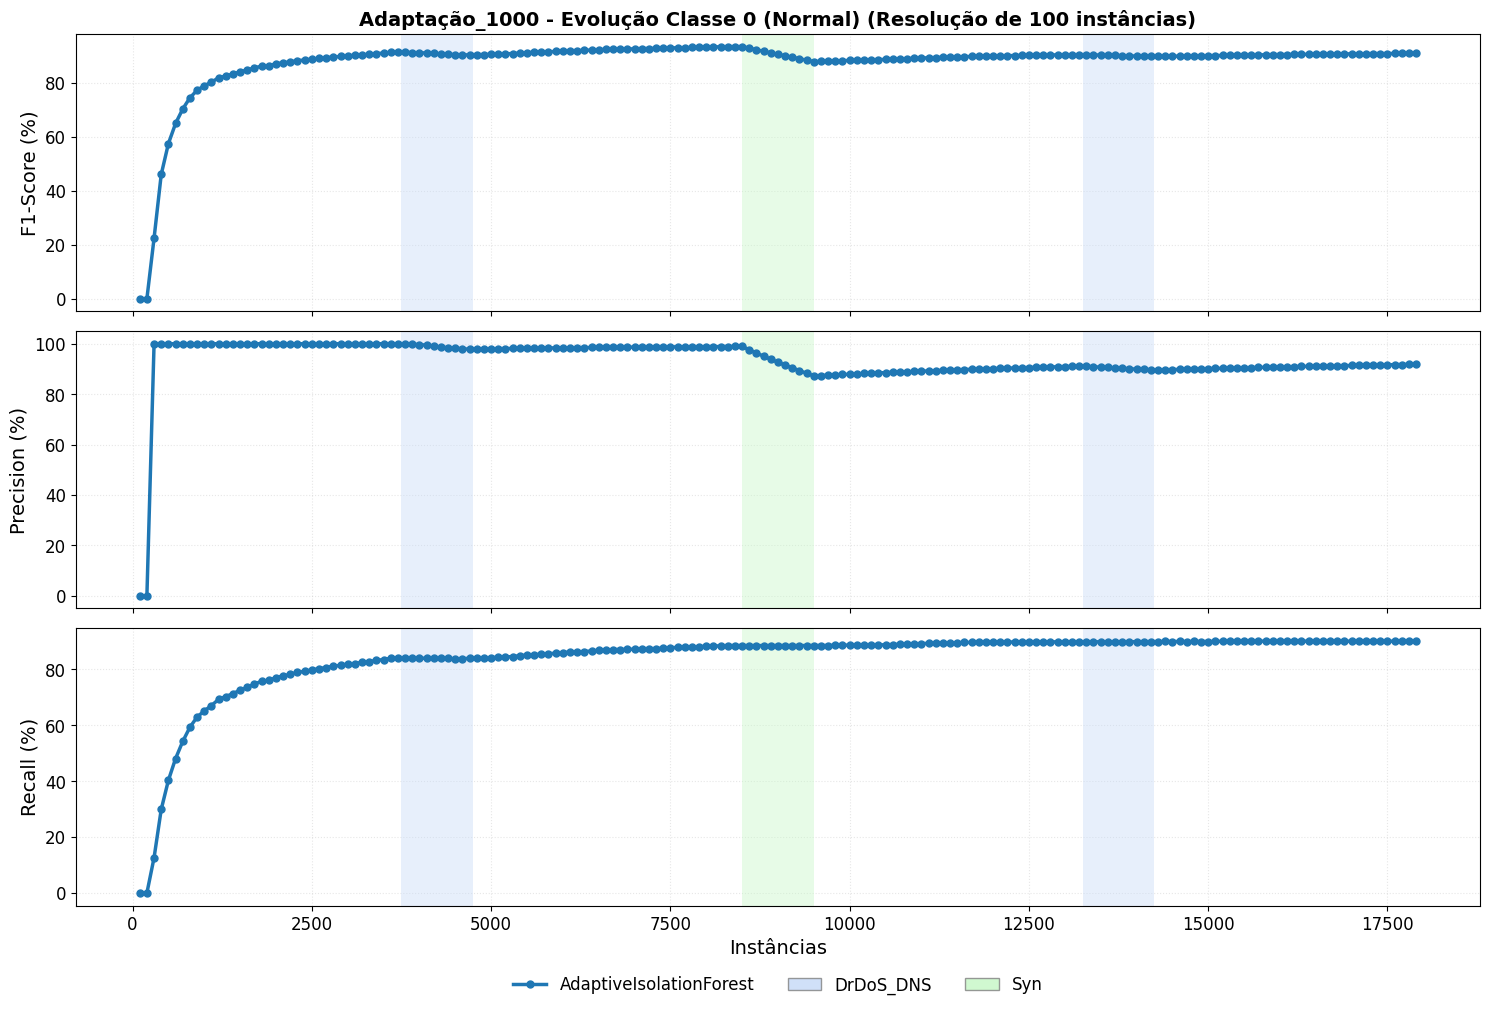


Iniciando treinamento para: Recorrência_25

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 94.80    | 99.82    | 90.26    | 0.127    | 4.76      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.02%   | Recuperação (1000 amostras): +2.71%
  -> Ataque 2: Passagem: -0.13%   | Recuperação (1000 amostras): +1.11%
  -> Ataque 3: Passagem: -0.01%   | Recuperação (1000 amostras): +0.51%
  -> Ataque 4: Passagem: -0.01%   | Recuperação (1000 amostras): +0.42%
  -> Ataque 5: Passagem: -0.05%   | Recuperação (1000 amostras): +0.08%
  -> Ataque 6: Passagem: 0.00%    | Recuperação (1000 amostras): -0.02%



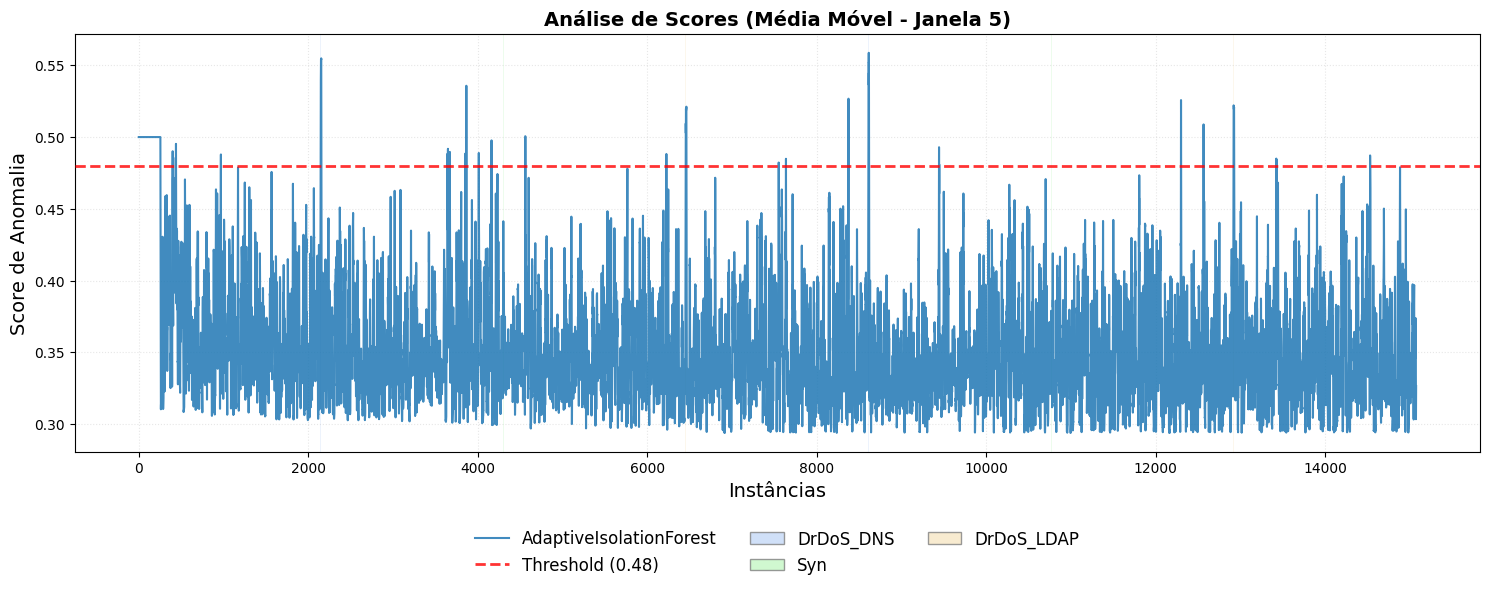

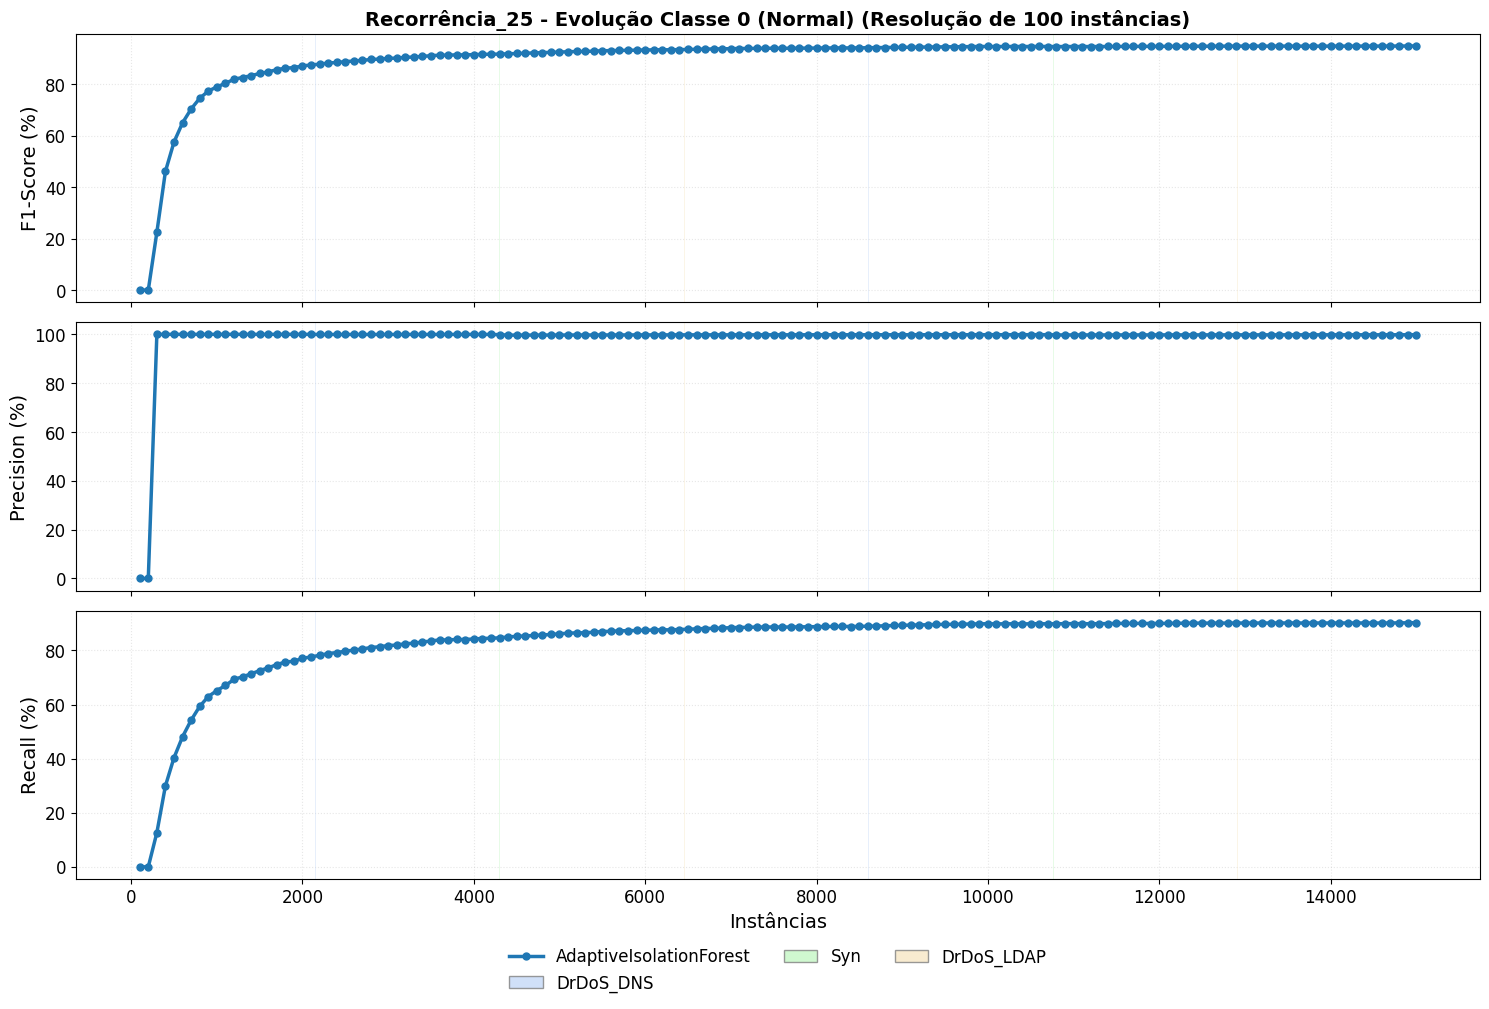


Iniciando treinamento para: Recorrência_200

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 94.15    | 98.54    | 90.14    | 0.322    | 5.32      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.07%   | Recuperação (1000 amostras): +2.59%
  -> Ataque 2: Passagem: -1.06%   | Recuperação (1000 amostras): +1.32%
  -> Ataque 3: Passagem: -0.01%   | Recuperação (1000 amostras): +0.62%
  -> Ataque 4: Passagem: -0.06%   | Recuperação (1000 amostras): +0.50%
  -> Ataque 5: Passagem: -0.44%   | Recuperação (1000 amostras): +0.15%
  -> Ataque 6: Passagem: 0.00%    | Recuperação (1000 amostras): +0.03%



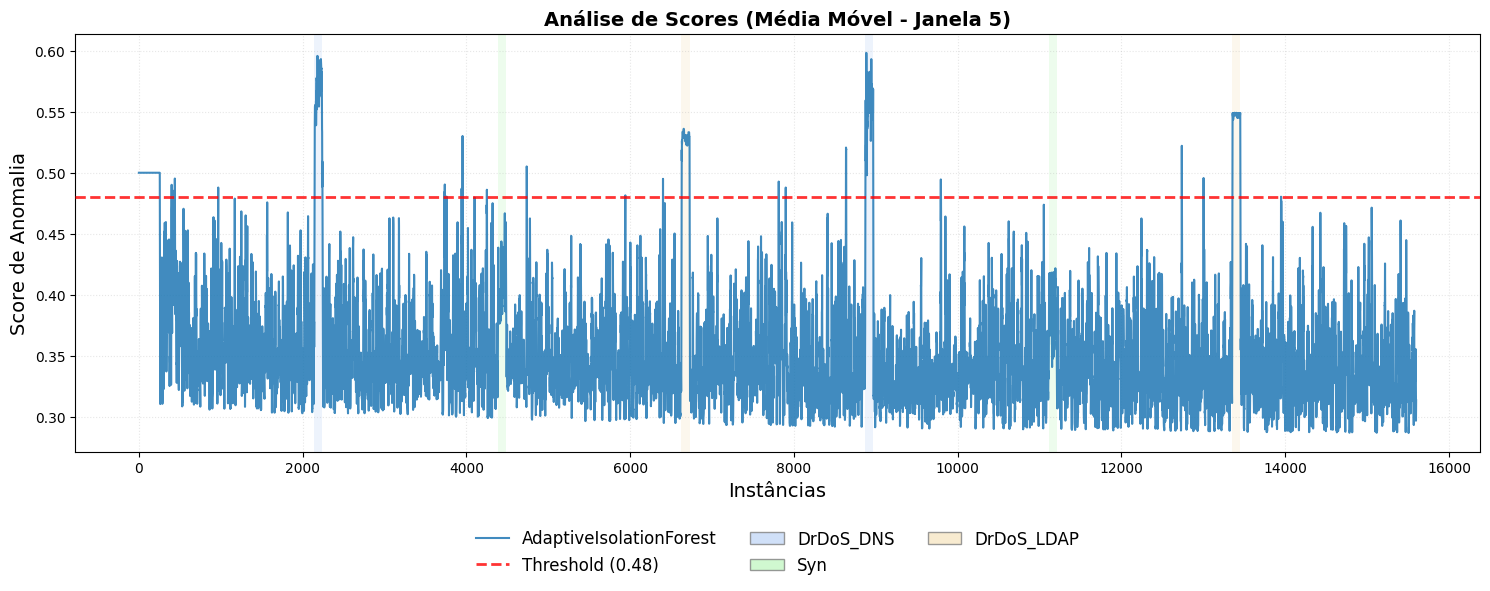

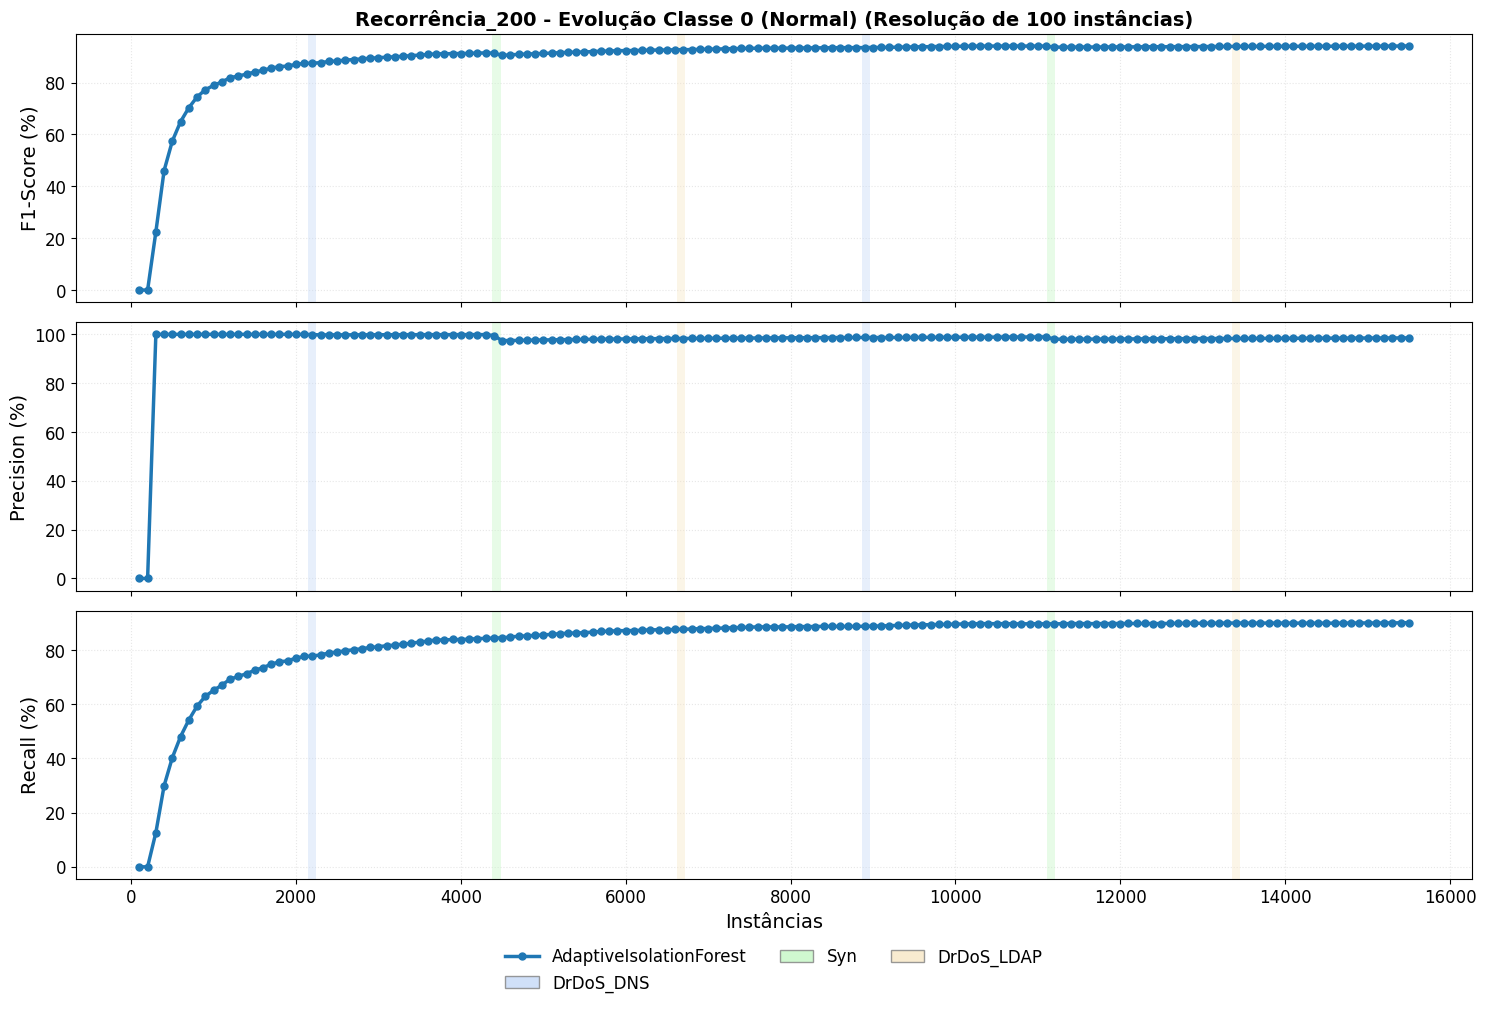


Iniciando treinamento para: Recorrência_1000

                      RELATÓRIO COMPORTAMENTAL - CLASSE 0                      
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | MCC      | Tempo (s) 
-------------------------------------------------------------------------------
AdaptiveIsolationForest | 91.33    | 93.21    | 89.52    | 0.473    | 6.02      
-------------------------------------------------------------------------------
  -> Ataque 1: Passagem: -0.87%   | Recuperação (1000 amostras): +2.82%
  -> Ataque 2: Passagem: -5.07%   | Recuperação (1000 amostras): +2.10%
  -> Ataque 3: Passagem: -0.01%   | Recuperação (1000 amostras): +0.96%
  -> Ataque 4: Passagem: -0.13%   | Recuperação (1000 amostras): +0.71%
  -> Ataque 5: Passagem: -1.93%   | Recuperação (1000 amostras): +0.38%
  -> Ataque 6: Passagem: 0.00%    | Recuperação (1000 amostras): +0.19%



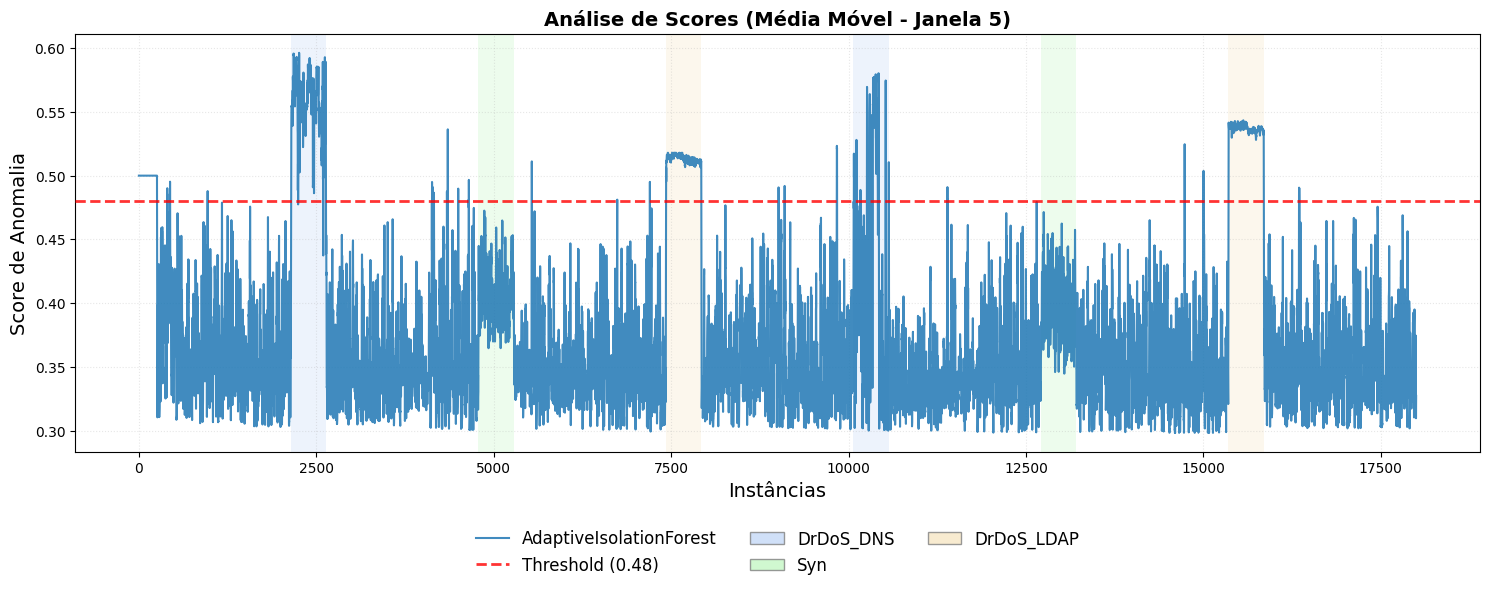

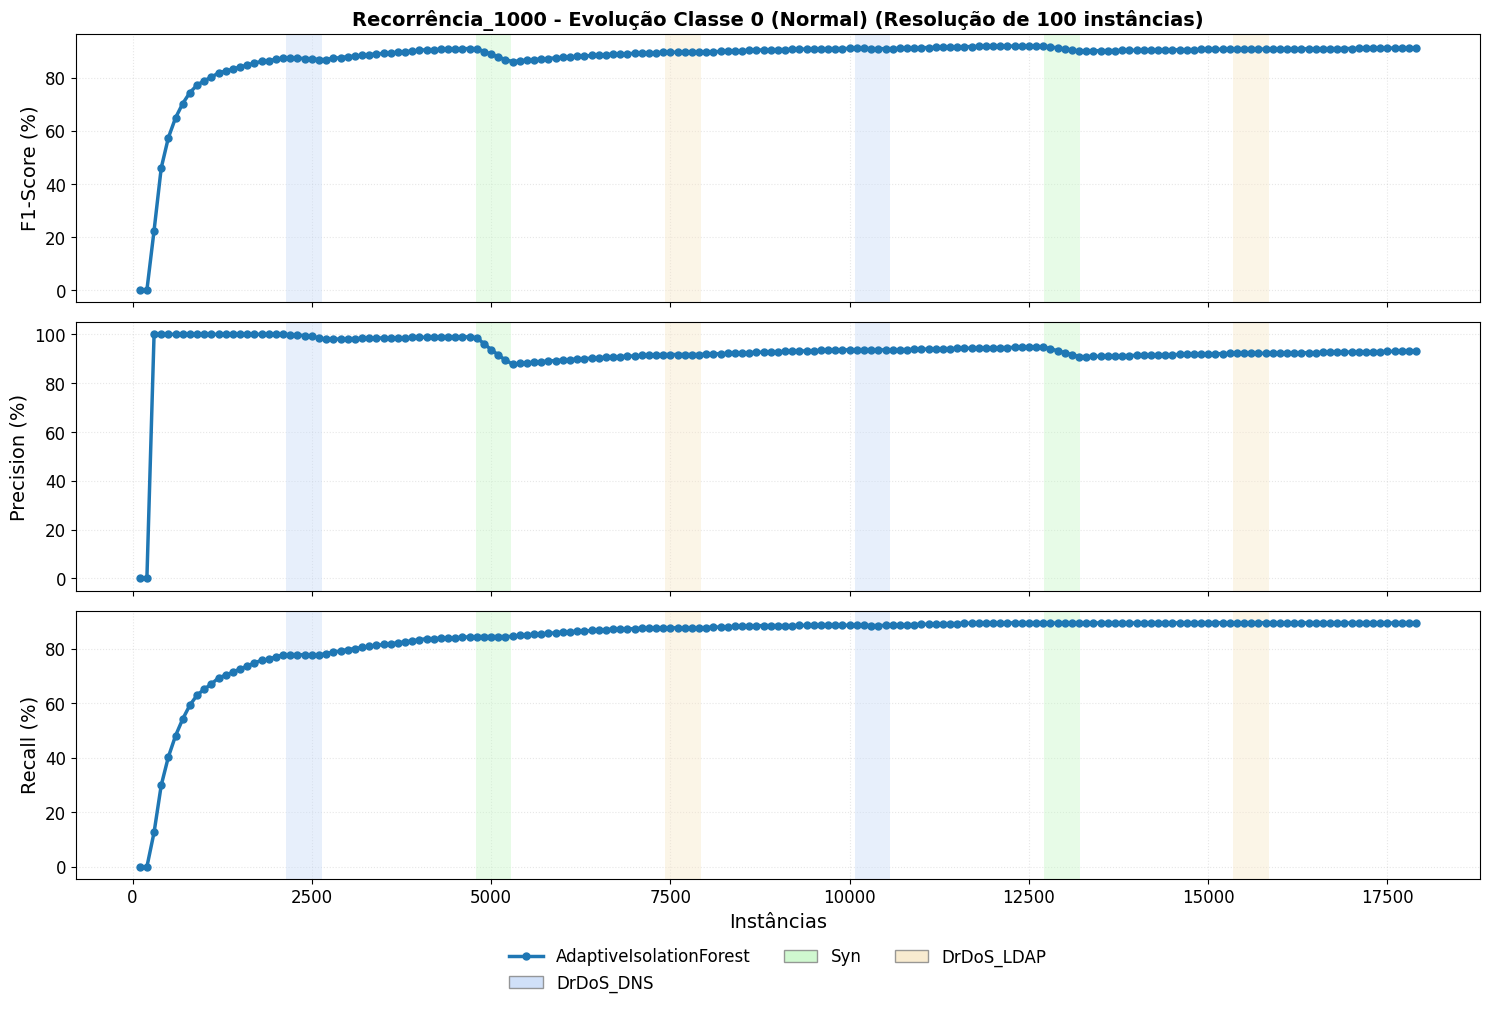

In [9]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor
import pandas as pd

categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '200', '1000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

features = [
    'Fwd Packet Length Min',
    'Total Fwd Packets',
    'Fwd Packet Length Max',
    'Packet Length Variance',
    'Init_Win_bytes_forward',
    'Flow IAT Mean',
    'Fwd Packets/s',
    'Fwd Packet Length Std',
    'Flow Duration',
    'Total Backward Packets',
    'URG Flag Count',
    'Init_Win_bytes_backward',
    'Flow IAT Min',
    'Bwd Packets/s',
    'Bwd IAT Mean',
    'Down/Up Ratio',
    'Bwd IAT Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Fwd Header Length',
    'Total Length of Fwd Packets',
    'ACK Flag Count',
    'Active Mean',
    'Fwd Packet Length Mean',
    'Fwd PSH Flags',
]

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=features)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=['AIF']
    )
    
    runner = AnomalyExperimentRunner(target_names=targets)
    
    runner._run_anomaly_evaluation(
        stream,
        algorithms=algoritmos,
        window_size=100,
        warmup_instances=0,
        title=nome_experimento,
        target_class=0,
        threshold=0.48
    )